In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('household_energy_consumption.csv')

In [3]:
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [4]:
df.shape

(90000, 7)

In [5]:
df.isnull().sum()

Household_ID              0
Date                      0
Energy_Consumption_kWh    0
Household_Size            0
Avg_Temperature_C         0
Has_AC                    0
Peak_Hours_Usage_kWh      0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB


In [8]:
df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,90000.000000,90000.000000,90000.000000,90000.000000
mean,10.571988,3.487811,17.505802,4.319557
std,5.519494,1.709761,2.491621,2.531432
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,3.000000,17.500000,4.000000
75%,14.800000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


In [9]:
df.columns

Index(['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size',
       'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh'],
      dtype='object')

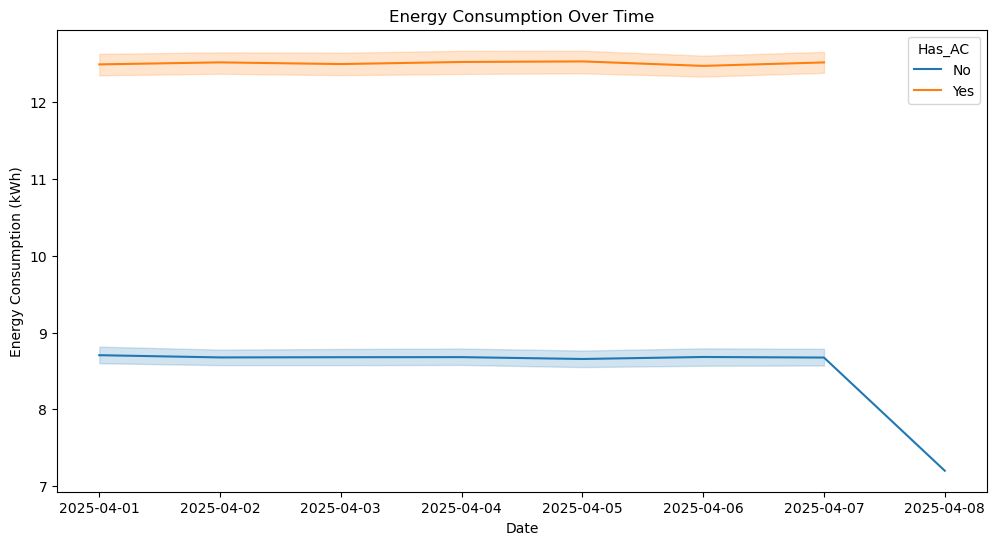

In [10]:
# To track energy consumption over time:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Energy_Consumption_kWh', hue='Has_AC')
plt.title('Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.show()


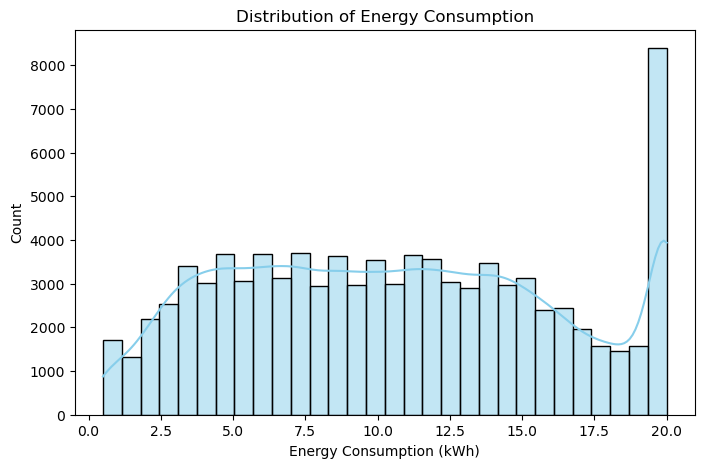

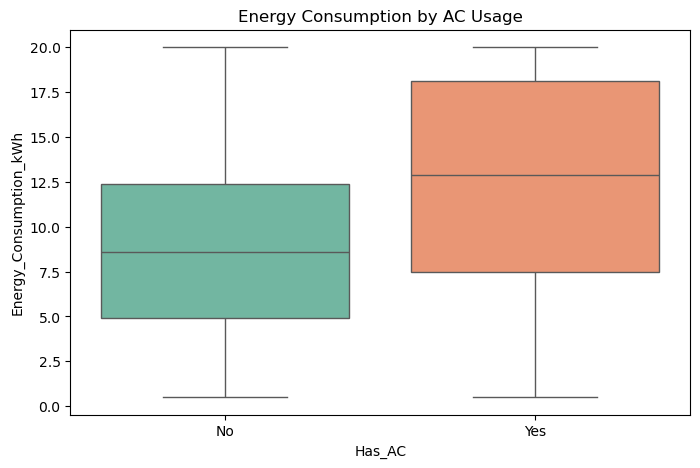

In [12]:
# For outliers and spread across households with/without AC:
plt.figure(figsize=(8,5))
sns.boxplot(x='Has_AC', y='Energy_Consumption_kWh', data=df, palette='Set2')
plt.title('Energy Consumption by AC Usage')
plt.show()


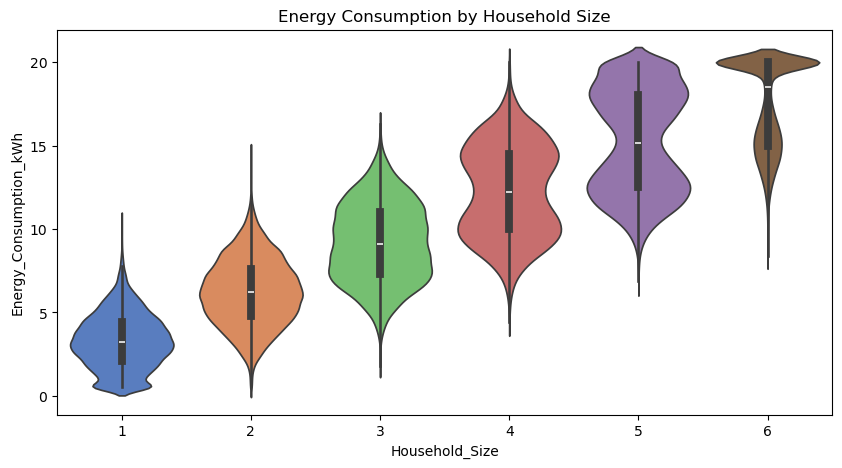

In [13]:
#To compare consumption by household size:
plt.figure(figsize=(10,5))
sns.violinplot(x='Household_Size', y='Energy_Consumption_kWh', data=df, palette='muted')
plt.title('Energy Consumption by Household Size')
plt.show()


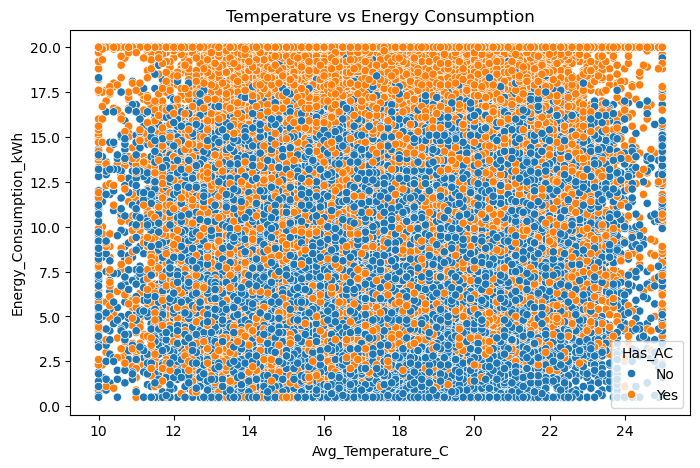

In [14]:
# To see relationship between temperature and energy:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Avg_Temperature_C', y='Energy_Consumption_kWh', hue='Has_AC', data=df)
plt.title('Temperature vs Energy Consumption')
plt.show()


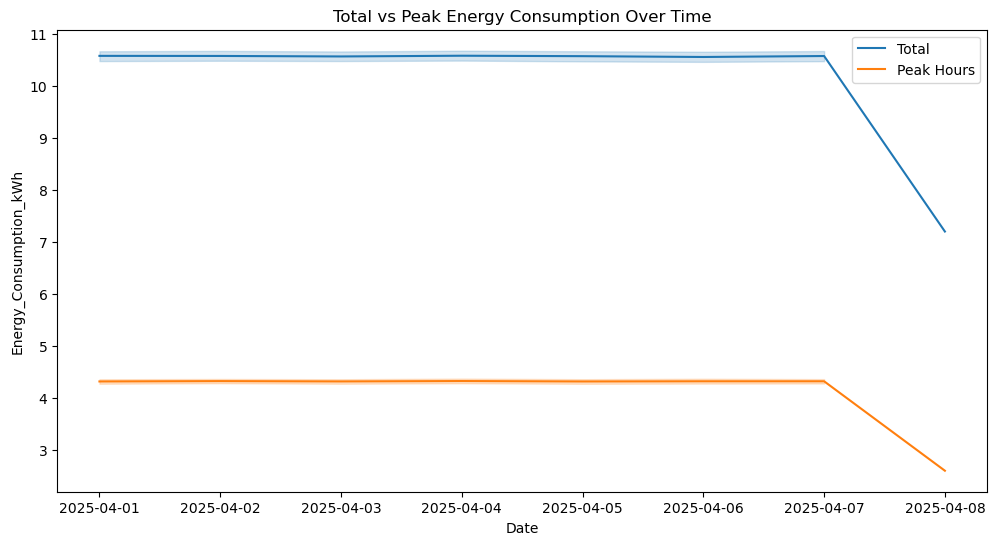

In [15]:
# Energy vs Peak usage:
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Energy_Consumption_kWh', data=df, label='Total')
sns.lineplot(x='Date', y='Peak_Hours_Usage_kWh', data=df, label='Peak Hours')
plt.title('Total vs Peak Energy Consumption Over Time')
plt.legend()
plt.show()


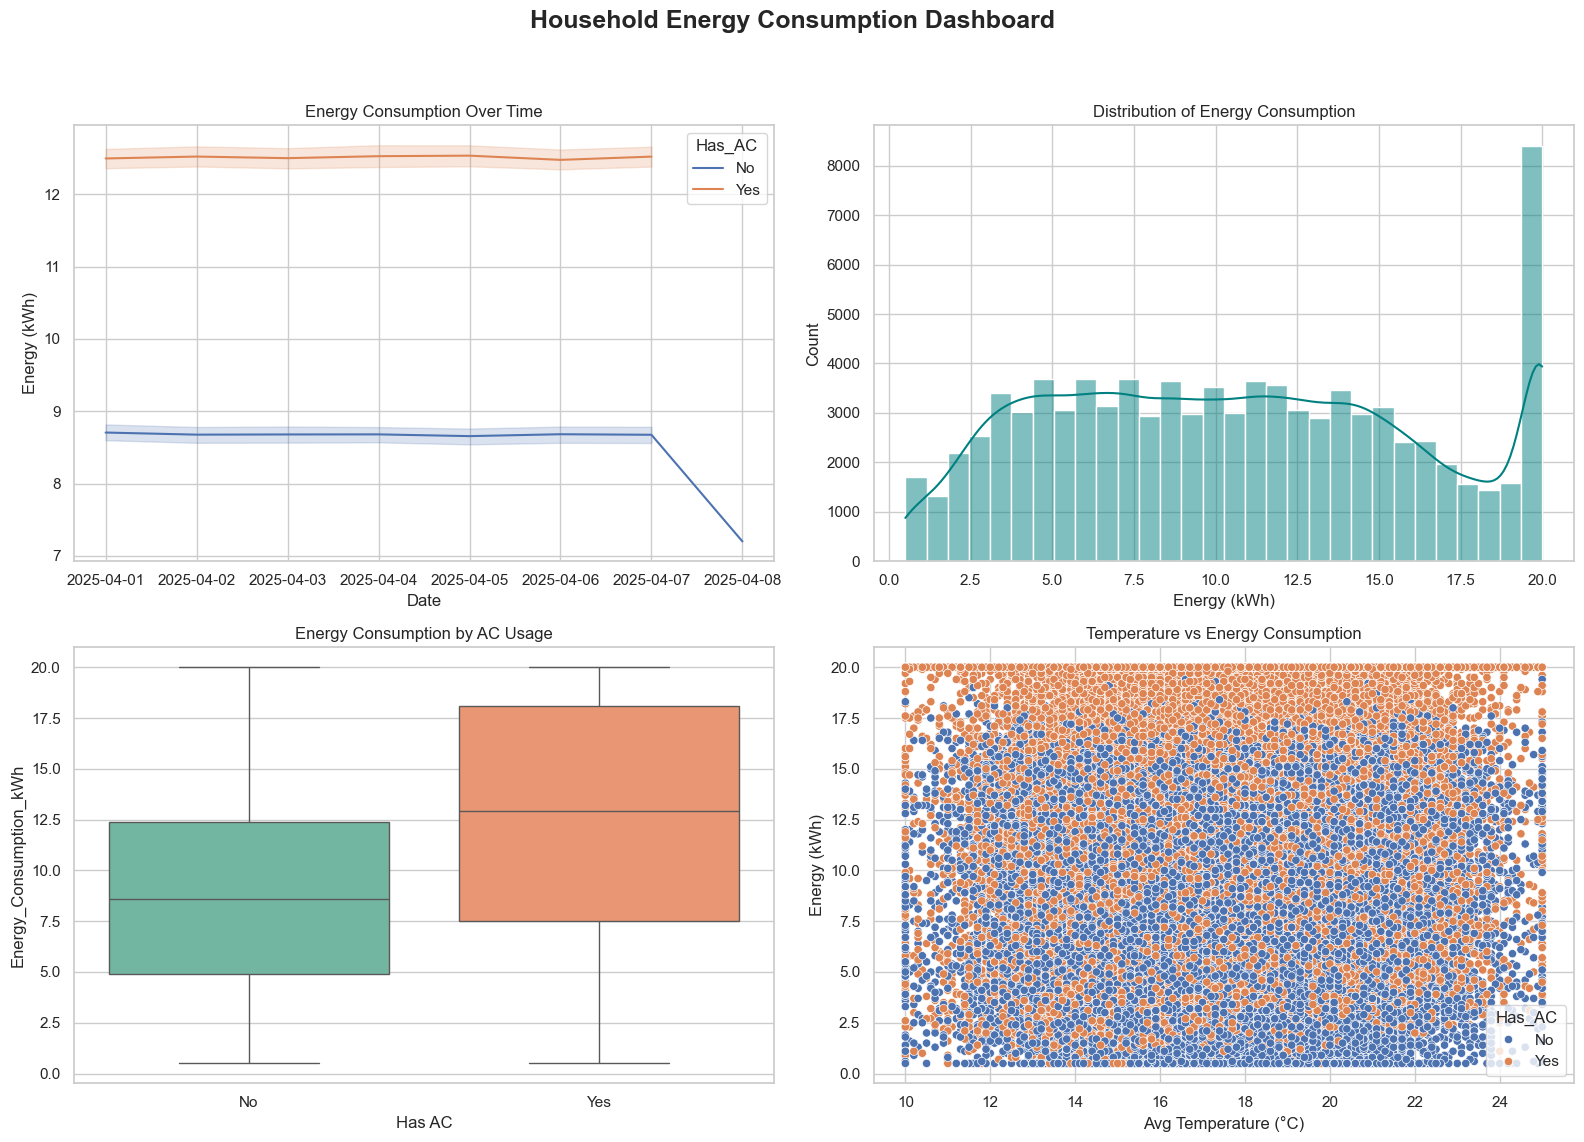

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Date column to datetime if not already
df['Date'] = pd.to_datetime(df['Date'])

# Set plot style
sns.set(style='whitegrid')

# Create a 2x2 dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Household Energy Consumption Dashboard', fontsize=18, fontweight='bold')

# 1. Line Plot: Energy Consumption Over Time
sns.lineplot(data=df, x='Date', y='Energy_Consumption_kWh', hue='Has_AC', ax=axes[0, 0])
axes[0, 0].set_title('Energy Consumption Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Energy (kWh)')

# 2. Histogram: Energy Consumption Distribution
sns.histplot(df['Energy_Consumption_kWh'], bins=30, kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of Energy Consumption')
axes[0, 1].set_xlabel('Energy (kWh)')

# 3. Boxplot: Energy by AC Presence
sns.boxplot(data=df, x='Has_AC', y='Energy_Consumption_kWh', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Energy Consumption by AC Usage')
axes[1, 0].set_xlabel('Has AC')

# 4. Scatter Plot: Temperature vs Energy Use
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Energy_Consumption_kWh', hue='Has_AC', ax=axes[1, 1])
axes[1, 1].set_title('Temperature vs Energy Consumption')
axes[1, 1].set_xlabel('Avg Temperature (°C)')
axes[1, 1].set_ylabel('Energy (kWh)')

# Tight layout adjustment
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


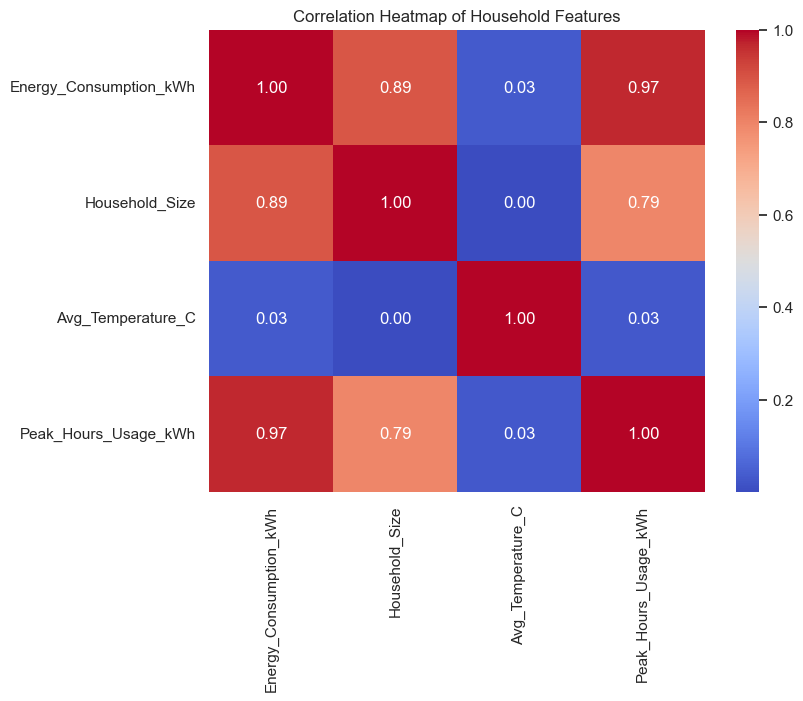

In [17]:
# Select only numeric columns
numeric_cols = ['Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C', 'Peak_Hours_Usage_kWh']
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Household Features')
plt.show()